In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.formula.api as smf

np.random.seed(42)

In [3]:
import os

games_df = pd.read_csv('data/gdelt_kalshi_nba.csv', parse_dates=['game_date'])
pregame_df = pd.read_csv('data/nba_pregame_features.csv', parse_dates=['game_date'])
print('gdelt_kalshi_nba.csv:     ', games_df.shape)
print('nba_pregame_features.csv:  ', pregame_df.shape)

print()
print('Games date range:', games_df['game_date'].min().date(), '→', games_df['game_date'].max().date())

gdelt_kalshi_nba.csv:      (1339, 24)
nba_pregame_features.csv:   (1194, 48)

Games date range: 2025-04-15 → 2026-04-21


In [8]:
#merge data
games_df = games_df.merge(pregame_df, on='event_ticker', how='left', suffixes=('', '_pregame'))
print(f'merged columns: {games_df.columns.tolist()}')

merged columns: ['event_ticker', 'game_date', 'team1', 'team2', 'winner', 'loser', 'winner_implied_prob', 'loser_implied_prob', 'team1_articles', 'team2_articles', 'team1_avg_tone', 'team2_avg_tone', 'team1_avg_positive', 'team2_avg_positive', 'team1_avg_negative', 'team2_avg_negative', 'team1_avg_polarity', 'team2_avg_polarity', 'mention_ratio_t1', 'tone_diff_t1_minus_t2', 'polarity_diff_t1_minus_t2', 'media_disparity_t1', 'pricing_error_winner', 'pricing_error_loser', 'game_date_pregame', 'team1_pregame', 'team2_pregame', 'winner_pregame', 'team1_home', 'season', 'winner_implied_prob_pregame', 't1_roll_win_pct', 't1_roll_pts', 't1_roll_opp_pts', 't1_roll_pm', 't1_roll_fg_pct', 't1_roll_fg3_pct', 't1_roll_ft_pct', 't1_roll_reb', 't1_roll_ast', 't1_roll_tov', 't1_roll_stl', 't1_roll_blk', 't1_rest_days', 't2_roll_win_pct', 't2_roll_pts', 't2_roll_opp_pts', 't2_roll_pm', 't2_roll_fg_pct', 't2_roll_fg3_pct', 't2_roll_ft_pct', 't2_roll_reb', 't2_roll_ast', 't2_roll_tov', 't2_roll_stl', 't

In [10]:
#column transformations
# media_disparity_loser: positive = losing team had MORE pre-game coverage
# media_disparity_t1 is positive when team1 has more articles
games_df['media_disparity_loser'] = np.where(
    games_df['winner'] == games_df['team1'],
    -games_df['media_disparity_t1'],   # team1 won -> loser is team2 -> flip sign
    games_df['media_disparity_t1']     # team2 won -> loser is team1 -> keep sign
)

games_df['team1_won'] = (games_df['winner'] == games_df['team1']).astype(int)
games_df['team1_implied_prob'] = np.where(
    games_df['team1_won'] == 1,
    games_df['winner_implied_prob'],
    games_df['loser_implied_prob']
)

# Convert team1 differential features into winner-advantage controls for OLS
# Positive values mean the eventual winner had stronger pregame form.
games_df['pregame_adv_roll_win_pct'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_win_pct'],
    -games_df['diff_roll_win_pct']
)
games_df['pregame_adv_roll_pm'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_pm'],
    -games_df['diff_roll_pm']
)
games_df['pregame_adv_rest_days'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_rest_days'],
    -games_df['diff_rest_days']
)

# --- Step 3: GDELT minimum-coverage filter ---
# Teams with very sparse mentions (<10 articles) produce unstable disparity scores
min_articles = 10
nb_before_filter = len(games_df)
games_df = games_df[
    (games_df['team1_articles'] >= min_articles) &
    (games_df['team2_articles'] >= min_articles)
].copy()
print(f'Rows before coverage filter: {nb_before_filter:,}')
print(f'Rows after coverage filter:  {len(games_df):,}')

# --- Step 4: Drop rows with any remaining nulls in analysis columns ---

nb_before_drop = len(games_df)
df = games_df.dropna().copy()
print(f'Rows after dropping nulls:   {len(df):,}  (dropped {nb_before_drop - len(df)})')

Rows before coverage filter: 1,251
Rows after coverage filter:  1,251
Rows after dropping nulls:   1,069  (dropped 182)


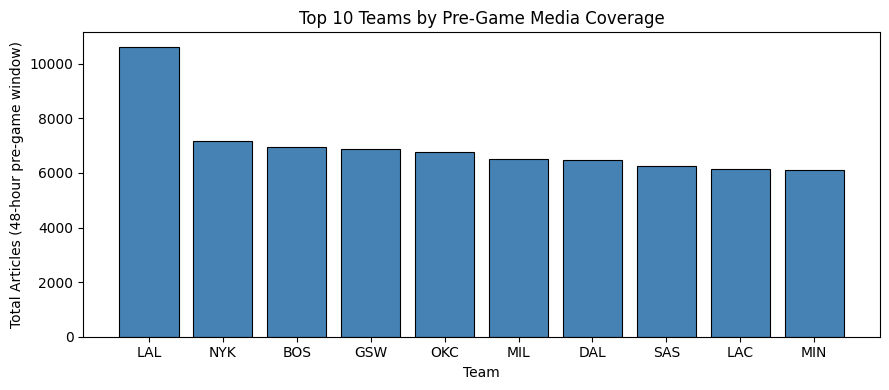

In [11]:
# Total article mentions per team across all games (team1 + team2 appearances)
team1_counts = df.groupby('team1')['team1_articles'].sum()
team2_counts = df.groupby('team2')['team2_articles'].sum()
total_coverage = (team1_counts.add(team2_counts, fill_value=0)
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(9, 4))
plt.bar(total_coverage.index, total_coverage.values, color='steelblue', edgecolor='black', linewidth=0.8)
plt.xlabel('Team')
plt.ylabel('Total Articles (48-hour pre-game window)')
plt.title('Top 10 Teams by Pre-Game Media Coverage')
plt.tight_layout()
plt.savefig('analysis/fig_coverage_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/2m/5s9qv8k95f191b61vh3y6zfr0000gp/T/ipykernel_52726/222473097.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df.groupby('prob_bin').agg(


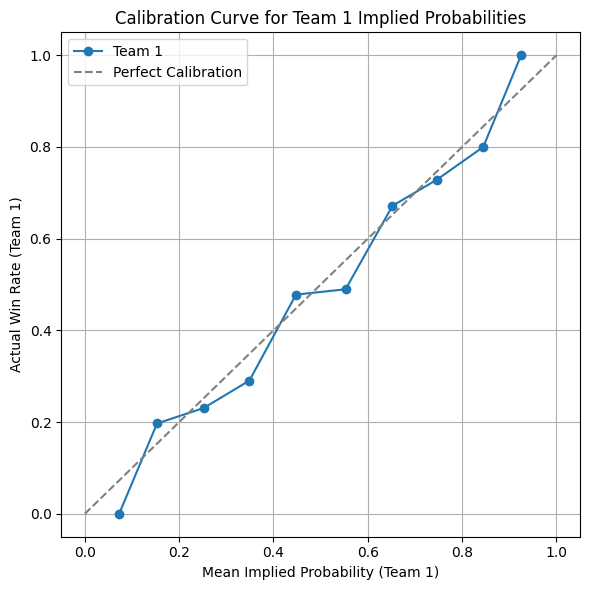

In [13]:
# plot calibration curve for team1 implied probabilities vs actual outcomes averaged by 10% bins
df['prob_bin'] = pd.cut(df['team1_implied_prob'], bins=np.arange(0, 1.1, 0.1))
calibration = df.groupby('prob_bin').agg(
    mean_implied_prob=('team1_implied_prob', 'mean'),
    actual_win_rate=('team1_won', 'mean'),
    count=('team1_won', 'count')
).reset_index()
plt.figure(figsize=(6, 6))
plt.plot(calibration['mean_implied_prob'], calibration['actual_win_rate'], marker='o', label='Team 1')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Implied Probability (Team 1)')
plt.ylabel('Actual Win Rate (Team 1)')
plt.title('Calibration Curve for Team 1 Implied Probabilities')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('analysis/fig_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

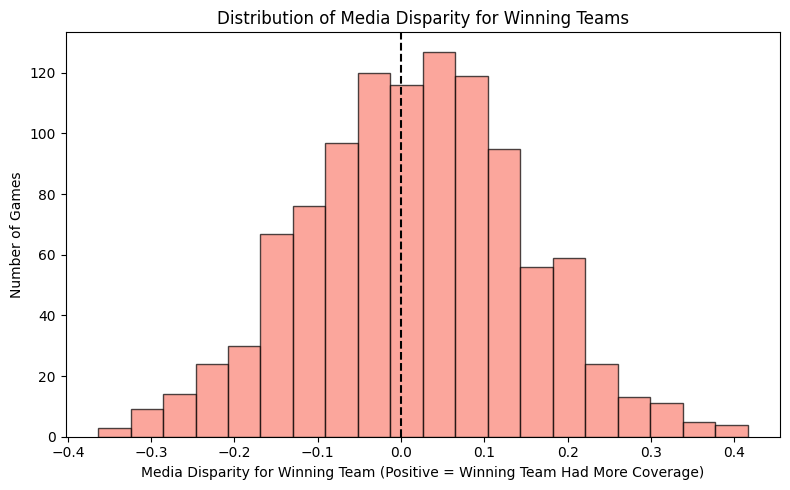

In [16]:
#plot media tone of winning vs losing teams
plt.figure(figsize=(8, 5))
winner_disparity = np.where(
    df['team1_won'] == 1,
    df['media_disparity_t1'],
    -df['media_disparity_t1']
)

plt.hist(winner_disparity, bins=20, alpha=0.7, color='salmon', edgecolor='black')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Media Disparity for Winning Team (Positive = Winning Team Had More Coverage)')
plt.ylabel('Number of Games')
plt.title('Distribution of Media Disparity for Winning Teams')
plt.tight_layout()
plt.savefig('analysis/fig_media_disparity_winner.png', dpi=150, bbox_inches='tight')
plt.show()  